In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
test = pd.read_csv(r'../test.csv')
train = pd.read_csv(r'../train.csv')

In [3]:
df = train.copy()

In [4]:
df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [5]:
test.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [7]:
df.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [8]:
cat_cols = [i for i in df.columns if df[i].dtype=='object']

In [9]:
for i in cat_cols:
    print(df[i].value_counts())
    print("-"*30)

gender
other     211097
male      210593
female    208310
Name: count, dtype: int64
------------------------------
course
b.tech     131236
b.sc       111554
b.com      110932
bca         88721
bba         75644
ba          61989
diploma     49924
Name: count, dtype: int64
------------------------------
internet_access
yes    579423
no      50577
Name: count, dtype: int64
------------------------------
sleep_quality
poor       213675
good       213089
average    203236
Name: count, dtype: int64
------------------------------
study_method
coaching         131697
self-study       131131
mixed            123086
group study      123009
online videos    121077
Name: count, dtype: int64
------------------------------
facility_rating
medium    214082
low       212378
high      203540
Name: count, dtype: int64
------------------------------
exam_difficulty
moderate    353982
easy        176540
hard         99478
Name: count, dtype: int64
------------------------------


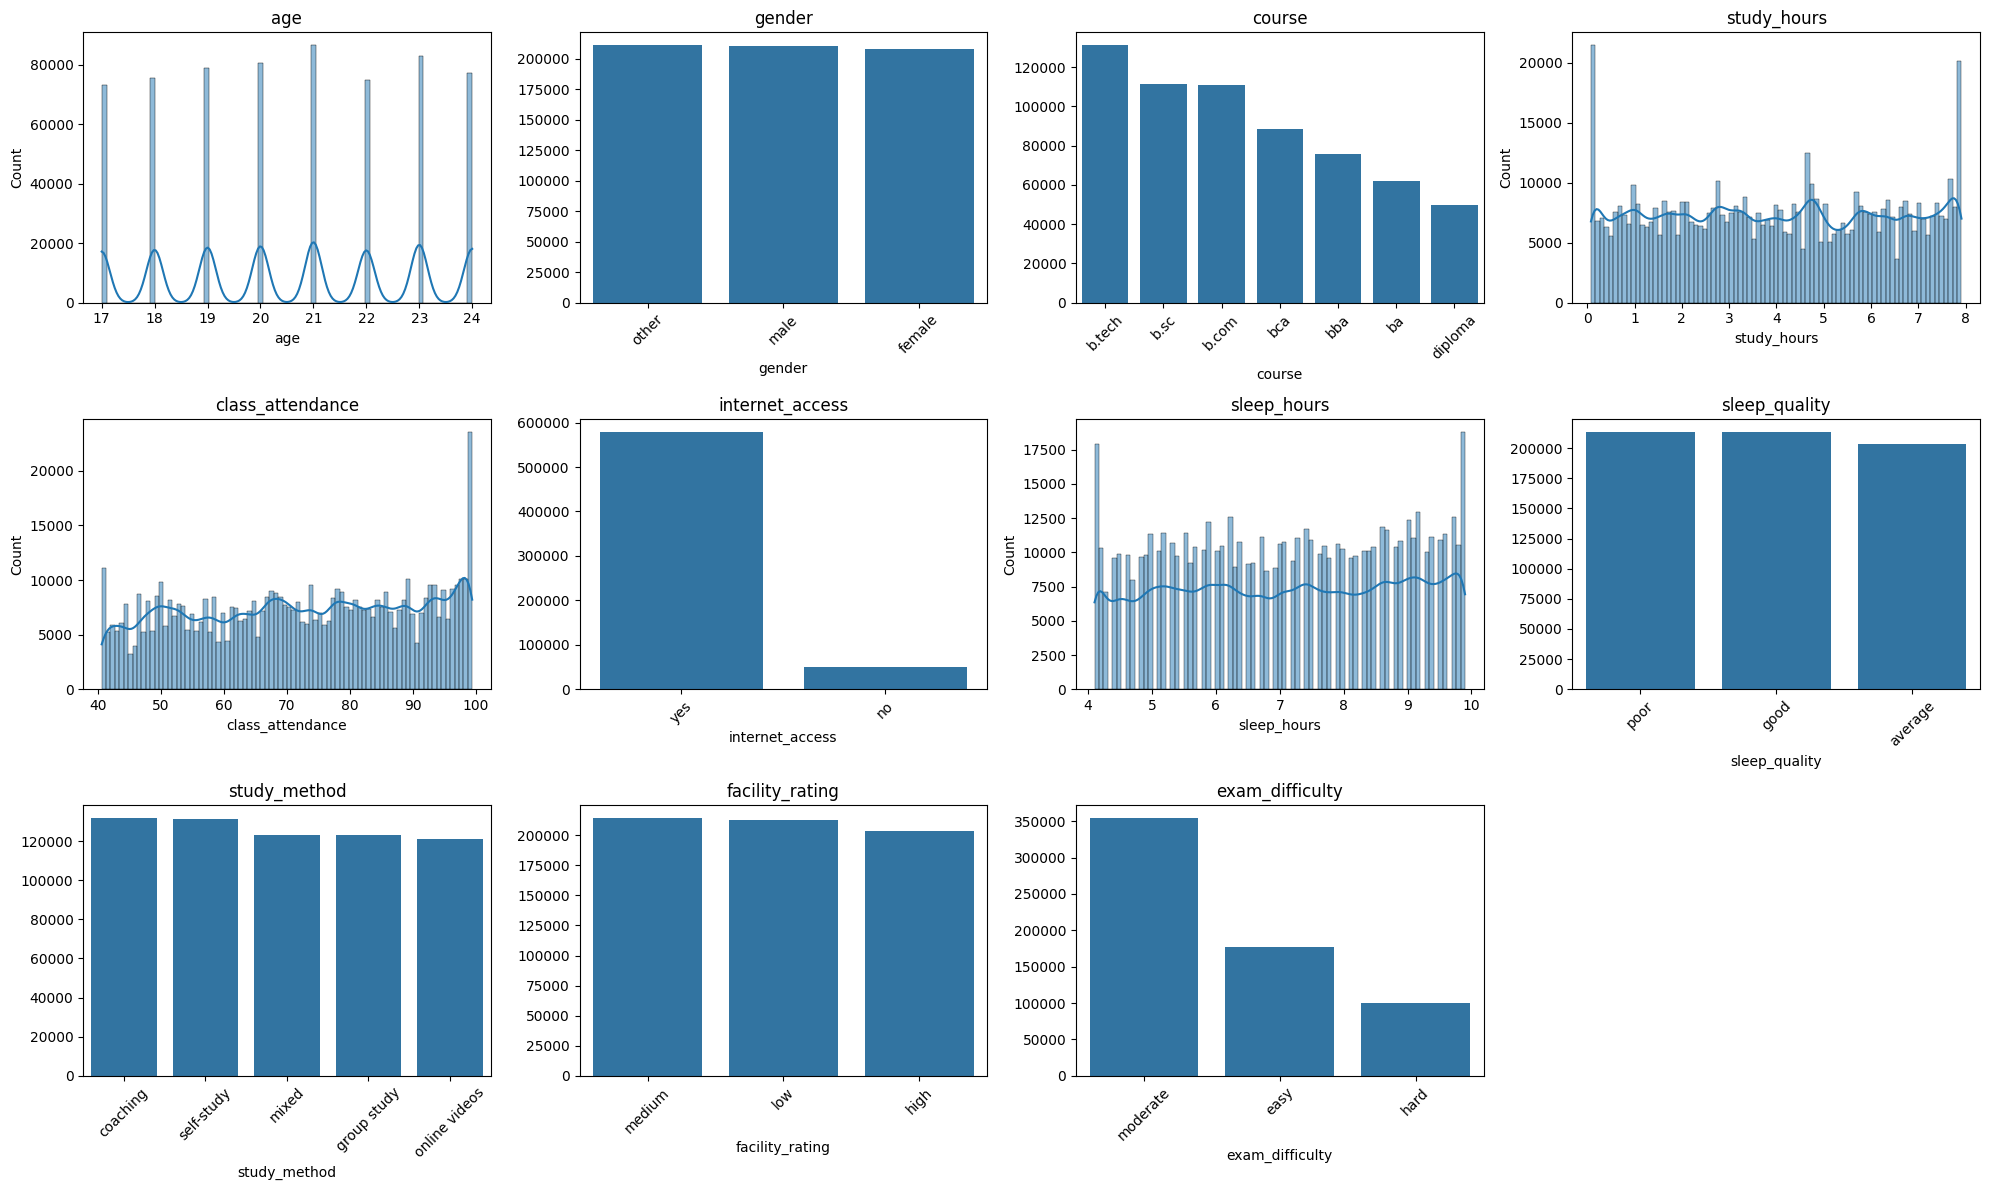

In [20]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_all_distributions_single_image(df, max_categories=15):
    cols = df.columns
    n_cols = 4
    n_rows = math.ceil(len(cols) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]

        if pd.api.types.is_numeric_dtype(df[col]):
            sns.histplot(df[col].dropna(), kde=True, ax=ax)
            ax.set_title(col)
        else:
            vc = df[col].value_counts().head(max_categories)
            sns.barplot(x=vc.index.astype(str), y=vc.values, ax=ax)
            ax.set_title(col)
            ax.tick_params(axis="x", rotation=45)

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_all_distributions_single_image(df.drop(columns=['id', 'exam_score']))


In [ ]:
df.colum

Index(['id', 'age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

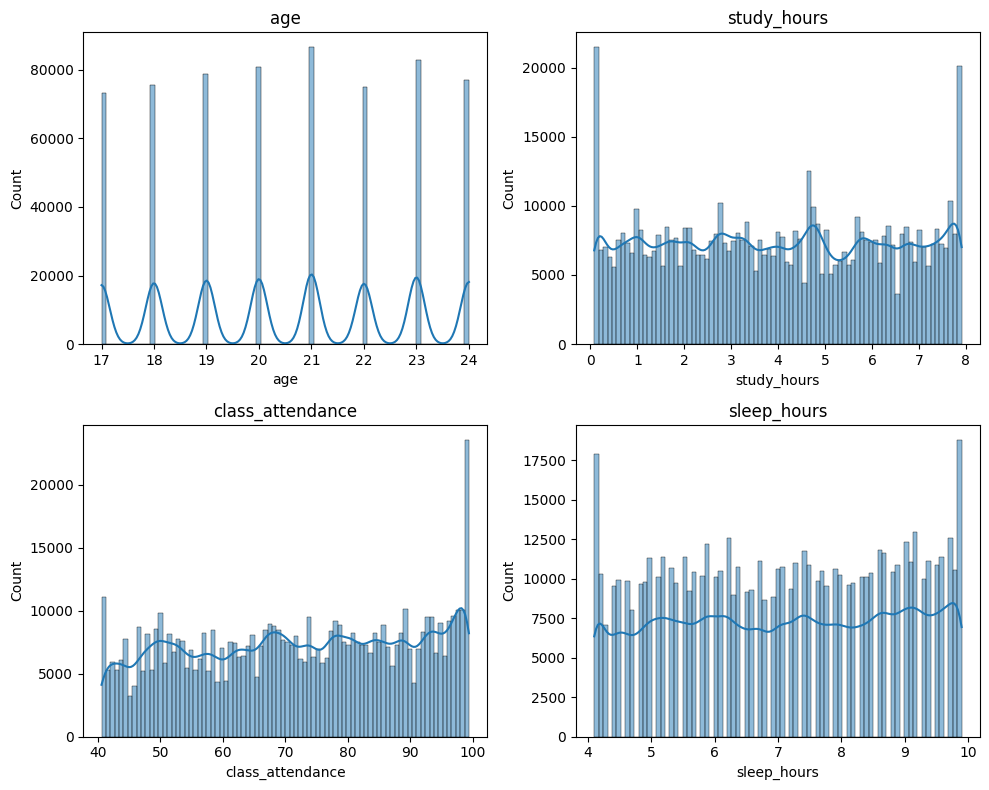

In [21]:
import math
def plot_numeric_distributions_single_image(df):
    numeric_cols = df.select_dtypes(include="number").columns

    n_cols = 2
    n_rows = math.ceil(len(numeric_cols) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
plot_numeric_distributions_single_image(df.drop(columns=['id', 'exam_score']))

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Drop identifier
df = train.copy()
df = df.drop(columns=["id"])

# Ordinal encodings (EXPLICIT)
df["sleep_quality"] = df["sleep_quality"].map(
    {"poor": 0, "average": 1, "good": 2}
)

df["facility_rating"] = df["facility_rating"].map(
    {"low": 0, "medium": 1, "high": 2}
)

df["exam_difficulty"] = df["exam_difficulty"].map(
    {"easy": 0, "moderate": 1, "hard": 2}
)

# df["study_internet"] = df["study_method"] + "_" + df["internet_access"]

# df = df.drop(columns=["study_method", "internet_access"])

categorical_cols = [
    "gender",
    "course",
    "internet_access",
    "study_method",
    # "study_internet",
    # "sleep_quality",
    # "facility_rating",
    # "exam_difficulty"
]

# for col in categorical_cols:
#     df[col] = df[col].astype("category")

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df.drop(columns=["exam_score"])
y = df["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


train_data = lgb.Dataset(
    X_train,
    label=y_train,
    # categorical_feature=categorical_cols,
    free_raw_data=False
)

valid_data = lgb.Dataset(
    X_test,
    label=y_test,
    # categorical_feature=categorical_cols,
    reference=train_data,
    free_raw_data=False
)

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbosity": -1,
    "seed": 42,
    "early_stopping_rounds": 50,
}

lgb_model = lgb.train(
    params,
    train_data,
    valid_sets=[valid_data],
    num_boost_round=500,
)

y_pred = lgb_model.predict(
    X_test, num_iteration=lgb_model.best_iteration
)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))


MAE: 6.9933725426154
RMSE: 8.766727861807887
R2: 0.7838995302233215


with ordinal baseline
```
MAE: 6.990338928244827
RMSE: 8.765322626170775
R2: 0.783968802989175
```

without ordinal baseline
```
MAE: 6.992066565388619
RMSE: 8.76710253512816
R2: 0.783881058380237
```

In [22]:
df.groupby("sleep_quality")["exam_score"].mean()


sleep_quality
average    62.662000
good       67.884885
poor       56.995470
Name: exam_score, dtype: float64

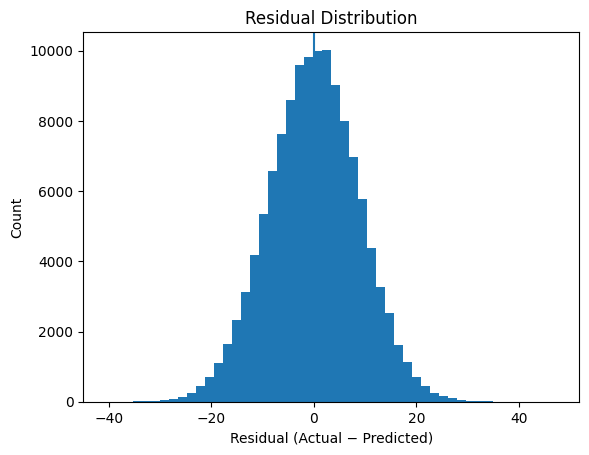

In [27]:
residuals = y_test.values - y_pred

res_df = X_test.copy()
res_df["actual"] = y_test.values
res_df["predicted"] = y_pred
res_df["residual"] = residuals
res_df["abs_residual"] = np.abs(residuals)

plt.figure()
plt.hist(residuals, bins=50)
plt.axvline(0)
plt.title("Residual Distribution")
plt.xlabel("Residual (Actual − Predicted)")
plt.ylabel("Count")
plt.show()


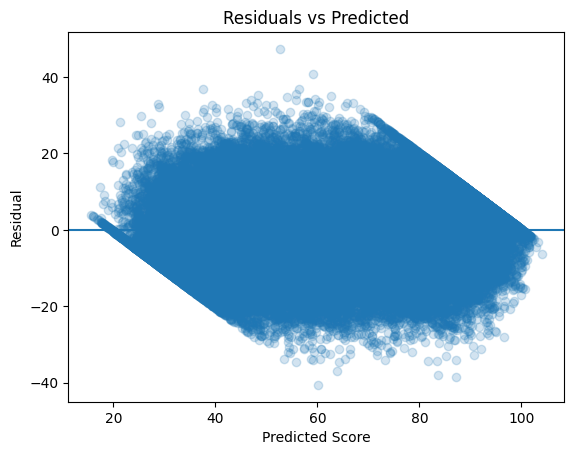

In [28]:
plt.figure()
plt.scatter(y_pred, residuals, alpha=0.2)
plt.axhline(0)
plt.xlabel("Predicted Score")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.show()


<Figure size 640x480 with 0 Axes>

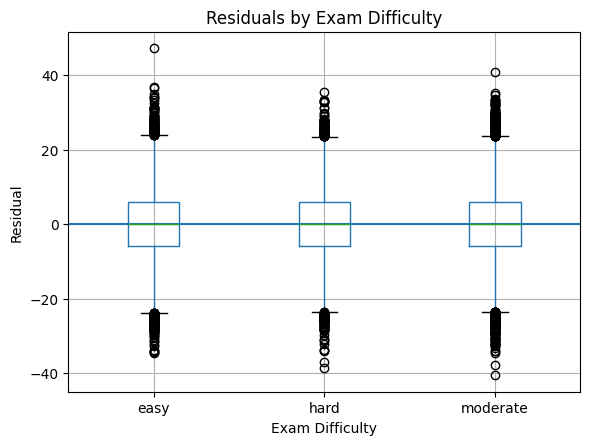

In [29]:
difficulty_map = {0: "easy", 1: "moderate", 2: "hard"}
res_df["exam_difficulty_label"] = res_df["exam_difficulty"].map(difficulty_map)

plt.figure()
res_df.boxplot(column="residual", by="exam_difficulty_label")
plt.axhline(0)
plt.title("Residuals by Exam Difficulty")
plt.suptitle("")
plt.xlabel("Exam Difficulty")
plt.ylabel("Residual")
plt.show()


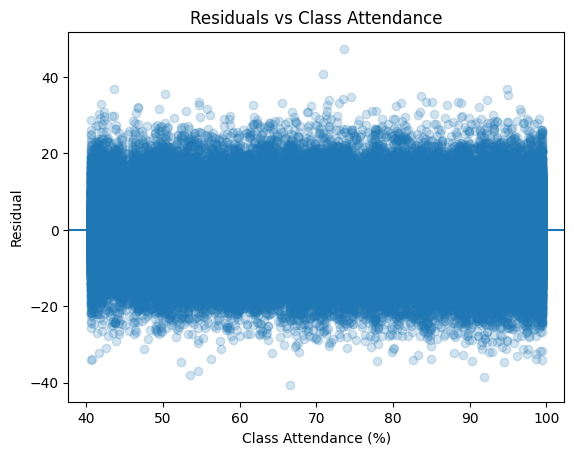

In [30]:
plt.figure()
plt.scatter(res_df["class_attendance"], residuals, alpha=0.2)
plt.axhline(0)
plt.xlabel("Class Attendance (%)")
plt.ylabel("Residual")
plt.title("Residuals vs Class Attendance")
plt.show()


In [31]:
group_error = (
    res_df
    .groupby(["study_method", "internet_access"])["residual"]
    .mean()
    .reset_index()
)

print(group_error.sort_values("residual"))


    study_method internet_access  residual
0       coaching              no -0.377186
6  online videos              no -0.311896
5          mixed             yes -0.094135
2    group study              no -0.055941
9     self-study             yes -0.018246
8     self-study              no  0.028635
7  online videos             yes  0.065177
1       coaching             yes  0.067416
3    group study             yes  0.112737
4          mixed              no  0.139066


C:\Users\16yas\AppData\Local\Temp\ipykernel_16776\3467181187.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["study_method", "internet_access"])["residual"]


In [32]:
res_df.sort_values("abs_residual", ascending=False).head(10)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,actual,predicted,residual,abs_residual,exam_difficulty_label
553891,21,other,diploma,1.73,73.6,no,7.5,2,mixed,0,0,100.000,52.685711,47.314289,47.314289,easy
87444,18,other,b.tech,2.85,70.9,yes,8.8,2,self-study,1,1,100.000,59.192709,40.807291,40.807291,moderate
199720,24,other,diploma,3.82,66.5,yes,6.7,0,coaching,1,1,19.599,60.176769,-40.577769,40.577769,moderate
450474,18,male,ba,6.03,91.9,yes,9.1,1,coaching,0,2,48.500,87.096671,-38.596671,38.596671,hard
354978,24,other,b.tech,7.32,53.5,yes,7.3,2,self-study,2,1,45.800,83.670238,-37.870238,37.870238,moderate
629254,17,other,b.tech,6.10,54.5,yes,6.3,0,self-study,2,2,26.800,63.761075,-36.961075,36.961075,hard
308258,22,female,bca,0.59,94.9,yes,9.2,1,mixed,2,0,93.300,56.355288,36.944712,36.944712,easy
479255,24,female,bba,0.08,43.6,yes,6.2,2,mixed,2,0,74.300,37.582951,36.717049,36.717049,easy
298935,20,male,bca,1.91,50.3,yes,9.7,1,coaching,2,2,91.200,55.788135,35.411865,35.411865,hard
572316,20,male,b.tech,0.08,95.0,yes,8.6,0,coaching,0,1,83.700,48.322111,35.377889,35.377889,moderate


C:\Users\16yas\AppData\Local\Temp\ipykernel_16776\621298184.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("attendance_bin")["abs_residual"]


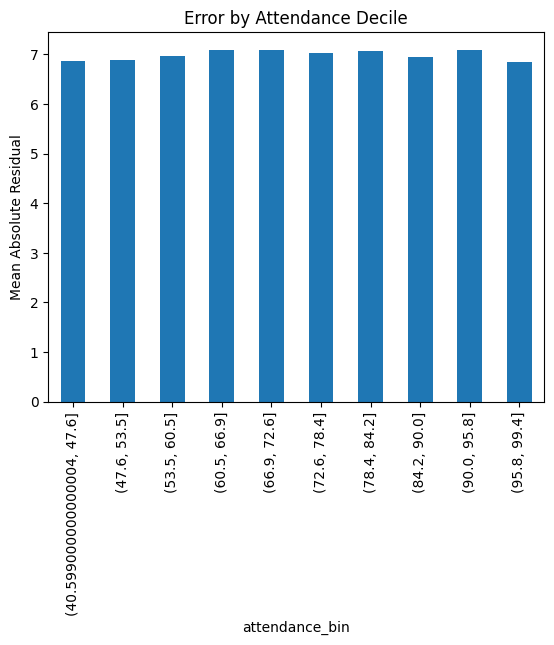

In [33]:
res_df["attendance_bin"] = pd.qcut(
    res_df["class_attendance"], q=10, duplicates="drop"
)

decile_error = (
    res_df
    .groupby("attendance_bin")["abs_residual"]
    .mean()
)

decile_error.plot(kind="bar")
plt.ylabel("Mean Absolute Residual")
plt.title("Error by Attendance Decile")
plt.show()


In [36]:
residuals

array([-9.71012433,  3.94523055, 18.07327417, ..., -2.49909499,
        0.79918862,  6.99176094], shape=(126000,))